# Pizarra multi-experto contra el baseline — tarea 1 (decisión de biopsia)

Este cuaderno responde a una sola pregunta: **¿la pizarra mejora o empeora el
baseline en la tarea 1, y dónde exactamente?**

## Cómo se mide, y por qué así

* **Evaluador oficial**, importado —no reimplementado— a través de
  `dev/score_local.py`, que a su vez carga el `evaluate.py` de los
  organizadores. Si cambian los pesos, estos números cambian con ellos.
* **Juez de razonamiento desactivado.** Es el modo determinista. Apagarlo
  *redistribuye* los pesos (el grounding pasa de 0.05 a 0.175, ×3.5), así que
  ningún número de aquí es comparable con uno de leaderboard. Sí lo es entre
  corridas medidas igual, que es exactamente para lo que se usa.
* **Casos sin salida contados como fallo** (`--count-missing`): es lo que hace
  Grand Challenge cuando un contenedor aborta.
* **Los 91 casos etiquetados** de `data/task1/ground_truth/`.

## Los cuatro puntos de comparación, y cuál es el válido

| corrida | qué es | temperatura |
|---|---|---|
| `ref T=1.0` | la línea base histórica del repo (`dev/baseline_reference.json`) | 1.0 |
| `base T=0` | el **control** del experimento del predictor (`delete_test/output_off`) | 0 |
| `run1` | la pizarra, primera corrida | 0 |
| `run2` | la pizarra con los prompts corregidos a partir de run1 | 0 |

> La única comparación A/B limpia es **`base T=0` contra `run1`/`run2`**: mismo
> modelo, mismos 91 casos, misma temperatura, mismo evaluador. Comparar contra
> `ref T=1.0` mezcla el efecto del diseño con el de la temperatura — a
> temperatura 1.0 el mismo caso acierta o falla según la tirada. Se muestra
> igualmente porque es el número que el repositorio cita como línea base.

In [1]:
import json, sys, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

REPO = Path.cwd()
while not (REPO / "src" / "chimera_agent_baseline").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
for p in (str(REPO), str(REPO / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

from delete_solution_one.solution_task_one.analysis import diagnose, scoring   # noqa: E402

SOL = REPO / "delete_solution_one" / "solution_task_one"
RUNS = {
    "base T=0": REPO / "delete_test" / "output_off",
    "run1": SOL / "runs" / "run1" / "output",
    "run2": SOL / "runs" / "run2" / "output",
}
RUNS = {k: v for k, v in RUNS.items() if v.is_dir()}
REF = json.loads((REPO / "dev" / "baseline_reference.json").read_text())["task1"]
print("corridas encontradas:", list(RUNS))

corridas encontradas: ['base T=0', 'run1', 'run2']


## 1. El número que ranquea

`ranking_score` de la tarea 1 = `(mean_case_score + F1(clase "yes")) / 2`.

`mean_case_score` se promedia sobre **todos** los casos, incluidos los que
fallan la puerta de decisión (que valen 0). Por eso la puerta domina: en T1 la
decisión es una condición, no una parte de la nota.

In [2]:
aggs = {name: scoring.score(root) for name, root in RUNS.items()}
rows = {name: scoring.summarise(a) for name, a in aggs.items()}

tabla = pd.DataFrame(rows).T
orden = ["ranking_score", "mean_case_score", "decision_gate", "f1_yes",
         "variable_weight_score", "confidence_score", "important_decisive_factor_score",
         "section_grounding_score", "tool_score", "n_missing"]
tabla = tabla[[c for c in orden if c in tabla.columns]]

ref_row = pd.Series({
    "ranking_score": REF["ranking_score"],
    "mean_case_score": REF["mean_case_score"],
    "decision_gate": REF["decision_gate_pass_rate"],
    "f1_yes": REF["decision_f1_yes"],
    "tool_score": REF["mean_tool_score"],
    "section_grounding_score": REF["mean_section_grounding_score"],
    "n_missing": 0,
}, name="ref T=1.0")
tabla = pd.concat([ref_row.to_frame().T, tabla])
display(tabla.astype(float).round(4))

,ranking_score,mean_case_score,decision_gate,f1_yes,tool_score,section_grounding_score,n_missing,variable_weight_score,confidence_score,important_decisive_factor_score
ref T=1.0,0.6351,0.4815,0.6703,0.7887,0.6645,1.0000,0.0,NaN,NaN,NaN
base T=0,0.6428,0.4913,0.6813,0.7943,0.6468,0.9960,0.0,0.6516,0.7661,0.5609
run1,0.6500,0.5113,0.6703,0.7887,0.7664,0.9087,0.0,0.7656,0.7295,0.6519
run2,0.6749,0.5499,0.6923,0.8000,0.7698,0.9138,0.0,0.8365,0.7063,0.7421


In [3]:
base = "base T=0"
print("Delta contra el control a la misma temperatura (base T=0):\n")
for name in RUNS:
    if name == base:
        continue
    d = {k: round(rows[name][k] - rows[base][k], 4)
         for k in ("ranking_score", "mean_case_score", "decision_gate", "f1_yes")
         if rows[name].get(k) is not None and rows[base].get(k) is not None}
    print(f"  {name:8} {d}")
print(f"\nDelta de la mejor corrida contra la referencia historica T=1.0 "
      f"({REF['ranking_score']:.4f}): "
      f"{max(rows[n]['ranking_score'] for n in RUNS) - REF['ranking_score']:+.4f}")

Delta contra el control a la misma temperatura (base T=0):

  run1     {'ranking_score': 0.0072, 'mean_case_score': 0.02, 'decision_gate': -0.011, 'f1_yes': -0.0056}
  run2     {'ranking_score': 0.0321, 'mean_case_score': 0.0586, 'decision_gate': 0.011, 'f1_yes': 0.0057}

Delta de la mejor corrida contra la referencia historica T=1.0 (0.6351): +0.0398


## 2. De dónde sale el cambio: los cinco componentes

Con el juez apagado, `case_score` de un caso que **pasa** la puerta es:

```
0.275·variable_weight + 0.225·confidence + 0.175·important_decisive
+ 0.175·section_grounding + 0.150·tool
```

Los componentes se calculan **sólo** sobre los casos que pasan la puerta, así
que hay que leerlos junto a la tasa de puerta: subir un componente sobre menos
casos no sube la nota.

,variable_weight_score,confidence_score,important_decisive_factor_score,section_grounding_score,tool_score
base T=0,0.6516,0.7661,0.5609,0.9960,0.6468
run1,0.7656,0.7295,0.6519,0.9087,0.7664
run2,0.8365,0.7063,0.7421,0.9138,0.7698


,variable_weight_score,confidence_score,important_decisive_factor_score,section_grounding_score,tool_score,suma (= case_score entre los que pasan),x tasa de puerta
base T=0,0.1792,0.1724,0.0982,0.1743,0.0970,0.7210,0.4912
run1,0.2105,0.1641,0.1141,0.1590,0.1150,0.7627,0.5113
run2,0.2300,0.1589,0.1299,0.1599,0.1155,0.7942,0.5498


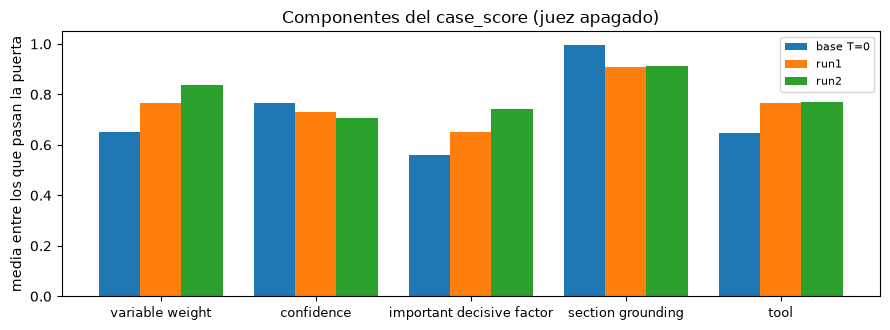

In [4]:
PESOS = {"variable_weight_score": 0.275, "confidence_score": 0.225,
         "important_decisive_factor_score": 0.175, "section_grounding_score": 0.175,
         "tool_score": 0.150}

comp = pd.DataFrame({n: {k: rows[n][k] for k in PESOS} for n in RUNS}).T
aporte = comp.mul(pd.Series(PESOS), axis=1)
aporte["suma (= case_score entre los que pasan)"] = aporte.sum(axis=1)
aporte["x tasa de puerta"] = aporte["suma (= case_score entre los que pasan)"] * comp.index.map(
    lambda n: rows[n]["decision_gate"])
display(comp.round(4))
display(aporte.round(4))

fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(PESOS)); w = 0.8 / len(RUNS)
for i, n in enumerate(RUNS):
    ax.bar(x + i * w, [comp.loc[n, k] for k in PESOS], w, label=n)
ax.set_xticks(x + w * (len(RUNS) - 1) / 2)
ax.set_xticklabels([k.replace("_score", "").replace("_", " ") for k in PESOS], fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("media entre los que pasan la puerta")
ax.legend(fontsize=8); ax.set_title("Componentes del case_score (juez apagado)")
plt.tight_layout(); plt.show()

## 3. La puerta: dónde están de verdad los puntos

El baseline tiene una patología conocida y medida: **nunca descarta**. Recall
1.00 en `yes` y 0.14 en `no`. Como 35 de los 91 casos son `no`, eso son 30
casos que valen cero antes de mirar el razonamiento.

La estructura clínica que lo explica está en el estado de biopsia previa:

* `bx = None` (biopsia-naive) — 24 casos, 20 `yes`. Pregunta: ¿hay lesión que muestrear?
* `bx = Negative` — 18 casos, 13 `yes`. Pregunta: ¿se falló algo la vez anterior?
* `bx = Positive` — 49 casos, **26 `no` / 23 `yes`**. Aquí el diagnóstico ya
  existe: la pregunta no es "¿tiene cáncer?" sino "¿cambiaría el manejo?".
  Este cubo es el que decide la tarea, y es donde el prompt del presidente
  concentra su marco de decisión.

In [5]:
gt = diagnose.ground_truth()

def confusion(agg):
    c = Counter()
    for r in agg["_rows"]:
        c[(r["gt_decision"], r["pred_decision"])] += 1
    return c

def recall_table(agg):
    c = confusion(agg)
    out = {}
    for cls in ("yes", "no"):
        tp = c[(cls, cls)]; sup = sum(v for (g, _), v in c.items() if g == cls)
        pred = sum(v for (_, p), v in c.items() if p == cls)
        out[f"recall {cls}"] = round(tp / sup, 3) if sup else None
        out[f"precision {cls}"] = round(tp / pred, 3) if pred else None
    out["accuracy"] = round(sum(c[(k, k)] for k in ("yes", "no")) / sum(c.values()), 3)
    return out

display(pd.DataFrame({n: recall_table(a) for n, a in aggs.items()}).T)
print()
for n, a in aggs.items():
    print(n, dict(sorted({f"gt={g}->pred={p}": v for (g, p), v in confusion(a).items()}.items())))

,recall yes,precision yes,recall no,precision no,accuracy
base T=0,1.0,0.659,0.171,1.0,0.681
run1,1.0,0.651,0.143,1.0,0.670
run2,1.0,0.667,0.200,1.0,0.692



base T=0 {'gt=no->pred=no': 6, 'gt=no->pred=yes': 29, 'gt=yes->pred=yes': 56}
run1 {'gt=no->pred=no': 5, 'gt=no->pred=yes': 30, 'gt=yes->pred=yes': 56}
run2 {'gt=no->pred=no': 7, 'gt=no->pred=yes': 28, 'gt=yes->pred=yes': 56}


In [6]:
def acc_by_bucket(agg):
    buckets = defaultdict(list)
    for r in agg["_rows"]:
        cid = r["case_id"]
        if cid not in gt:
            continue
        bx = str(gt[cid]["prompt"].get("bx"))
        buckets[bx].append(r["decision_correct"])
    return {k: round(np.mean(v), 3) for k, v in sorted(buckets.items())}

por_cubo = pd.DataFrame({n: acc_by_bucket(a) for n, a in aggs.items()}).T
por_cubo["n casos"] = None
display(por_cubo)
print("tamaño de cada cubo:",
      dict(Counter(str(g["prompt"].get("bx")) for g in gt.values())))

,Negative,None,Positive,n casos
base T=0,0.722,1.000,0.510,None
run1,0.778,0.917,0.510,None
run2,0.889,1.000,0.469,None


tamaño de cada cubo: {'Positive': 49, 'None': 24, 'Negative': 18}


## 4. Economía de herramientas

`tool_score` es **precisión**: `|reveladas ∩ reveladas_por_el_urólogo| / |reveladas|`.
Revelar de menos no penaliza; revelar de más, sí. No revelar nada da 1.0.

Frecuencia con la que el urólogo reveló cada sección en los 91 casos:
`radiology_report` 0.97 · `psa_trend` 0.87 · `previous_notes` 0.85 ·
`laboratory_results` 0.45 · `family_history` **0.00**.

De ahí las dos reglas del prompt de L2: abrir siempre el informe de MRI y la
trayectoria de PSA, abrir el laboratorio sólo con una pregunta concreta, y
**no llamar nunca** a la anamnesis familiar.

In [7]:
def reveal_rates(agg, output_root):
    rates = Counter(); n = 0
    for r in agg["_rows"]:
        cid = r["case_id"]
        f = Path(output_root) / "task1" / cid / "prostate-biopsy-decision-reasoning.json"
        if not f.exists():
            continue
        n += 1
        for s in set(json.loads(f.read_text()).get("reveal_sequence") or []):
            rates[s] += 1
    return {k: round(v / n, 3) for k, v in rates.most_common()}, n

GT_RATE = diagnose.GT_REVEAL_RATE
tabla_rev = {"urólogo (gt)": GT_RATE}
for n_, a in aggs.items():
    tabla_rev[n_], _ = reveal_rates(a, RUNS[n_])
display(pd.DataFrame(tabla_rev).T.fillna(0).round(3))
print("\ntool_score medio (entre los que pasan la puerta):",
      {n: rows[n]["tool_score"] for n in RUNS})

,radiology_report,psa_trend,previous_notes,laboratory_results,family_history
urólogo (gt),0.967,0.868,0.846,0.451,0.000
base T=0,1.000,1.000,0.901,0.890,0.868
run1,1.000,1.000,1.000,1.000,0.000
run2,1.000,1.000,1.000,1.000,0.000



tool_score medio (entre los que pasan la puerta): {'base T=0': 0.6468, 'run1': 0.7664, 'run2': 0.7698}


## 5. Confianza y pesos de variables

* `confidence_score` = `1 − |conf_gt − conf_pred| / 2` con
  `uncertain=0, borderline=1, clear=2`. El urólogo puso `clear` en el 64 % de
  los casos, `borderline` en el 20 % y `uncertain` en el 16 %.
* `variable_weight_score` = `1 − media(|w_gt − w_pred|) / 3` sobre las
  variables del ground truth; una variable que no se declare cuenta como
  `not_used`.
* `important_decisive_factor_score` = **F1 de conjuntos** entre las variables
  marcadas `important`/`decisive`. Marcar de más y de menos penalizan igual.

In [8]:
def conf_dist(agg, output_root):
    pred, pares = Counter(), Counter()
    for r in agg["_rows"]:
        cid = r["case_id"]
        f = Path(output_root) / "task1" / cid / "prostate-biopsy-decision-reasoning.json"
        if not f.exists() or cid not in gt:
            continue
        c = json.loads(f.read_text()).get("confidence")
        pred[c] += 1
        pares[(gt[cid]["reasoning"]["confidence"], c)] += 1
    return pred, pares

gt_conf = Counter(g["reasoning"]["confidence"] for g in gt.values())
d = {"urólogo (gt)": {k: round(v / len(gt), 3) for k, v in gt_conf.items()}}
for n_, a in aggs.items():
    p, _ = conf_dist(a, RUNS[n_])
    tot = sum(p.values())
    d[n_] = {k: round(v / tot, 3) for k, v in p.items()}
display(pd.DataFrame(d).T.fillna(0))

,clear,borderline,uncertain
urólogo (gt),0.637,0.198,0.165
base T=0,0.978,0.022,0.000
run1,0.879,0.121,0.000
run2,0.462,0.396,0.143


In [9]:
ESCALA = {"not_used": 0, "noted": 1, "important": 2, "decisive": 3}

def weight_profile(output_root):
    acc = defaultdict(list)
    for cid in gt:
        f = Path(output_root) / "task1" / cid / "prostate-biopsy-decision-reasoning.json"
        if not f.exists():
            continue
        for k, v in (json.loads(f.read_text()).get("variable_weights") or {}).items():
            acc[k].append(ESCALA.get(v, 0))
    return {k: round(np.mean(v), 2) for k, v in sorted(acc.items())}

perfil = {"urólogo (gt)": {k: round(np.mean([ESCALA[g["reasoning"]["variable_weights"][k]]
                                             for g in gt.values()
                                             if k in g["reasoning"]["variable_weights"]]), 2)
                           for k in sorted(next(iter(gt.values()))["reasoning"]["variable_weights"])}}
for n_ in RUNS:
    perfil[n_] = weight_profile(RUNS[n_])
display(pd.DataFrame(perfil).T.fillna(0))
print("escala: 0 not_used · 1 noted · 2 important · 3 decisive")

,age,bx,comorbidity,cspca,dre,fh,pirads,psa,psad,vol
urólogo (gt),1.67,1.87,0.85,0.46,1.26,0.77,2.47,1.77,1.29,1.18
base T=0,0.47,0.00,0.13,2.38,0.07,0.27,2.96,2.47,1.22,0.37
run1,0.68,1.81,0.57,0.30,0.62,0.00,2.77,2.84,1.75,0.95
run2,2.00,1.54,1.04,0.00,1.02,0.00,2.57,2.31,1.56,1.00


escala: 0 not_used · 1 noted · 2 important · 3 decisive


## 6. Qué cambió entre run1 y run2, y si el cambio es señal o ruido

Las correcciones de prompt se decidieron leyendo las 91 pizarras de `run1`,
no adivinando. El diagnóstico de comportamiento está abajo; el detalle de qué
se cambió y por qué está en `runs/CORRECCIONES.md`.

Prueba de signos por caso: con `n` casos que cambian, ¿cuántos suben y cuántos
bajan? Un 50/50 es ruido, por muy grande que sea el delta agregado.

In [10]:
diags = {}
for name in ("run1", "run2"):
    d = SOL / "runs" / name
    if (d / "summary.jsonl").exists():
        diags[name] = diagnose.analyse(diagnose.load_run(d))

claves = ["accuracy", "accuracy_by_prior_biopsy", "pred_decision_dist", "reveal_rate",
          "n_reveals_dist", "mean_tool_precision", "confidence_pred_dist", "l1_rag_calls",
          "l2_rounds_dist", "l3_fallbacks", "l3_retry_cases", "prompt_echo_hits",
          "l2_raw_json_dumps", "free_text_uses_retrieved_evidence_rate",
          "free_text_names_the_conference_rate", "free_text_untraceable_rate",
          "mean_free_text_chars", "mean_seconds", "n_failed"]
for k in claves:
    print(f"{k}:")
    for n_, d in diags.items():
        print(f"   {n_:5} {d.get(k)}")

accuracy:
   run1  0.6703
   run2  0.6923
accuracy_by_prior_biopsy:
   run1  {'Negative': {'n': 18, 'acc': 0.778}, 'None': {'n': 24, 'acc': 0.917}, 'Positive': {'n': 49, 'acc': 0.51}}
   run2  {'Negative': {'n': 18, 'acc': 0.889}, 'None': {'n': 24, 'acc': 1.0}, 'Positive': {'n': 49, 'acc': 0.469}}
pred_decision_dist:
   run1  {'no': 5, 'yes': 86}
   run2  {'yes': 84, 'no': 7}
reveal_rate:
   run1  {'radiology_report': 1.0, 'psa_trend': 1.0, 'previous_notes': 1.0, 'laboratory_results': 1.0}
   run2  {'radiology_report': 1.0, 'psa_trend': 1.0, 'previous_notes': 1.0, 'laboratory_results': 1.0}
n_reveals_dist:
   run1  {4: 91}
   run2  {4: 91}
mean_tool_precision:
   run1  0.783
   run2  0.783
confidence_pred_dist:
   run1  {'borderline': 11, 'clear': 80}
   run2  {'borderline': 36, 'clear': 42, 'uncertain': 13}
l1_rag_calls:
   run1  0
   run2  91
l2_rounds_dist:
   run1  {1: 90, 4: 1}
   run2  {1: 91}
l3_fallbacks:
   run1  []
   run2  []
l3_retry_cases:
   run1  []
   run2  []
prompt_ec

run2 contra base T=0 sobre 91 casos
  suben 54 · bajan 11 · empatan 26
  delta medio +0.0586   prueba de signos p = 0.000


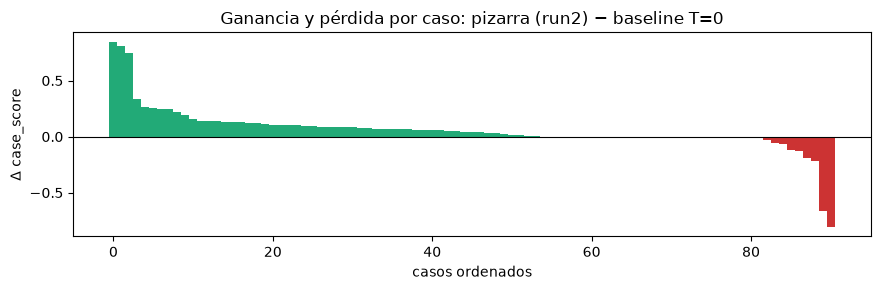

In [11]:
def case_scores(agg):
    return {r["case_id"]: r["case_score"] for r in agg["_rows"]}

if "run2" in aggs:
    a, b = case_scores(aggs["base T=0"]), case_scores(aggs["run2"])
    comunes = sorted(set(a) & set(b))
    delta = np.array([b[c] - a[c] for c in comunes])
    suben, bajan, iguales = int((delta > 0).sum()), int((delta < 0).sum()), int((delta == 0).sum())
    from scipy import stats
    p = stats.binomtest(suben, suben + bajan, 0.5).pvalue if suben + bajan else 1.0
    print(f"run2 contra base T=0 sobre {len(comunes)} casos")
    print(f"  suben {suben} · bajan {bajan} · empatan {iguales}")
    print(f"  delta medio {delta.mean():+.4f}   prueba de signos p = {p:.3f}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(range(len(delta)), np.sort(delta)[::-1], width=1.0,
           color=["#2a7" if d > 0 else "#c33" if d < 0 else "#bbb" for d in np.sort(delta)[::-1]])
    ax.axhline(0, color="k", lw=.8); ax.set_ylabel("Δ case_score"); ax.set_xlabel("casos ordenados")
    ax.set_title("Ganancia y pérdida por caso: pizarra (run2) − baseline T=0")
    plt.tight_layout(); plt.show()

In [12]:
if "run2" in aggs:
    filas = []
    for c in comunes:
        ra, rb = next(r for r in aggs["base T=0"]["_rows"] if r["case_id"] == c), \
                 next(r for r in aggs["run2"]["_rows"] if r["case_id"] == c)
        filas.append({"case_id": c, "gt": ra["gt_decision"],
                      "bx": str(gt[c]["prompt"].get("bx")) if c in gt else None,
                      "pirads": gt[c]["prompt"].get("pirads") if c in gt else None,
                      "base": ra["pred_decision"], "run2": rb["pred_decision"],
                      "Δcase": round(rb["case_score"] - ra["case_score"], 3)})
    df = pd.DataFrame(filas)
    rec = df[(df["base"] != df["gt"]) & (df["run2"] == df["gt"])].sort_values("Δcase", ascending=False)
    per = df[(df["base"] == df["gt"]) & (df["run2"] != df["gt"])].sort_values("Δcase")
    print(f"Casos que la pizarra RECUPERA (el baseline fallaba la puerta, run2 acierta): {len(rec)}")
    display(rec)
    print(f"Casos que la pizarra PIERDE (el baseline acertaba, run2 falla): {len(per)}")
    display(per)
    print(f"\nbalance neto de la puerta: {len(rec) - len(per):+d} casos")

Casos que la pizarra RECUPERA (el baseline fallaba la puerta, run2 acierta): 3


,case_id,gt,bx,pirads,base,run2,Δcase
53,PT-pseudo_47d8b39fd07f,no,Negative,3,yes,no,0.848
63,PT-pseudo_4f33b0253633,no,Negative,3,yes,no,0.807
71,PT-pseudo_c12bcf838ec8,no,Negative,3,yes,no,0.749


Casos que la pizarra PIERDE (el baseline acertaba, run2 falla): 2


,case_id,gt,bx,pirads,base,run2,Δcase
4,PT-pseudo_0615b2bd8504,no,Positive,5,no,yes,-0.808
48,PT-pseudo_3cc88c81f35a,no,Positive,2,no,yes,-0.665



balance neto de la puerta: +1 casos


## 6bis. El criterio de decisión: tres problemas, no uno

La tarea 1 no es un problema homogéneo. Cruzando el estado de biopsia previa
con la decisión del urólogo salen tres cubos, y sólo dos están determinados por
el panel visible. El análisis completo está en
[`CRITERIO_DIAGNOSTICO.md`](../CRITERIO_DIAGNOSTICO.md); aquí se reproducen sus
medidas para que se vean junto a los resultados.

In [13]:
import io, contextlib
from delete_solution_one.solution_task_one.analysis import criterio as crit

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    import sys as _s
    _argv = _s.argv
    _s.argv = ["criterio", "--run", "runs/run2" if (SOL / "runs" / "run2" / "output").is_dir() else "runs/run1"]
    try:
        crit.main()
    finally:
        _s.argv = _argv
print(buf.getvalue())

casos etiquetados: 91   dev/val: Counter({'dev': 64, 'val': 27})

=== 1. Los tres cubos clínicos ===
  bx = None      n= 24  {'yes': 20, 'no': 4}
      por PI-RADS: {2: {'no': 3}, 4: {'yes': 5}, 5: {'yes': 15}, NA: {'no': 1}}
      criterio de protocolo: 24/24
      confianza declarada por el urólogo: {'clear': 22, 'borderline': 2}
  bx = Negative  n= 18  {'yes': 13, 'no': 5}
      por PI-RADS: {3: {'no': 3}, 4: {'yes': 8, 'no': 1}, 5: {'yes': 5, 'no': 1}}
      criterio de protocolo: 16/18
      confianza declarada por el urólogo: {'borderline': 3, 'clear': 11, 'uncertain': 4}
  bx = Positive  n= 49  {'no': 26, 'yes': 23}
      por PI-RADS: {2: {'no': 2}, 3: {'yes': 2, 'no': 2}, 4: {'yes': 11, 'no': 8}, 5: {'yes': 10, 'no': 14}}
      criterio de protocolo: se abstiene
      confianza declarada por el urólogo: {'clear': 25, 'uncertain': 11, 'borderline': 13}

=== 2. ¿Separa alguna variable estructurada dentro de bx = Positive? ===
  psa      AUC=0.472  (n=49)
  age      AUC=0.548  (n=

In [14]:
# ¿siguió el presidente al experto de protocolo cuando éste sí daba respuesta?
from delete_solution_one.solution_task_one.experts.protocol import criterion as _crit

for name in ("run1", "run2"):
    d = SOL / "runs" / name / "blackboards"
    if not d.is_dir():
        continue
    sigue = falla = total = 0
    for f in sorted(d.glob("*.json")):
        b = json.loads(f.read_text())
        cid = b["case_id"]
        if cid not in gt:
            continue
        v = _crit(gt[cid]["prompt"])["verdict"]
        if v is None:
            continue
        chair = next(e for e in b["entries"] if e["speaker"] == "LLM-3-CHAIR")["data"]
        dec = "yes" if chair["biopsy_decision"] else "no"
        total += 1
        sigue += dec == v
        falla += dec != v and v == gt[cid]["decision"]
    if total:
        print(f"{name}: el presidente coincide con el criterio en {sigue}/{total} casos donde el "
              f"criterio se pronuncia; se aparta y se equivoca en {falla}")

run1: el presidente coincide con el criterio en 38/42 casos donde el criterio se pronuncia; se aparta y se equivoca en 4
run2: el presidente coincide con el criterio en 42/42 casos donde el criterio se pronuncia; se aparta y se equivoca en 0


## 7. Lectura honesta

Cinco formas de leer mal esta comparación, y cómo se evitan aquí:

1. **Excluir los casos sin salida** → número optimista. Todo lo de arriba usa
   `count_missing=True`.
2. **Comparar un número con juez contra uno sin juez.** Todos los de aquí son
   sin juez. Con el juez activo el `free_text` pesa 0.20 y el grounding cae a
   0.05: el reparto cambia, y este diseño invierte bastante en el texto libre,
   así que el efecto medido aquí es probablemente un **suelo**.
3. **Comparar contra `ref T=1.0`.** Es la línea base que cita el repositorio,
   pero es *una tirada* a temperatura 1.0. El control legítimo es `base T=0`.
4. **Optimizar el `tool_score` sin mirar la puerta.** Un componente sube sobre
   los casos que pasan; si pasan menos casos, la nota baja igual.
5. **Declarar mejora con un delta agregado y una prueba de signos 50/50.** La
   prueba está arriba; si sale p alto, el delta no es atribuible al diseño.

Además: los prompts se ajustaron leyendo `run1`, que incluye los 91 casos
etiquetados. Para una estimación limpia hay que mirar el split `val`
(27 casos, nunca usado para decidir nada) — se calcula abajo.

In [15]:
print("Sólo el split val (27 casos, no usado para ajustar prompts):\n")
val_rows = {}
for n_, root in RUNS.items():
    a = scoring.score(root, split="val")
    if a:
        val_rows[n_] = scoring.summarise(a)
display(pd.DataFrame(val_rows).T[["ranking_score", "mean_case_score", "decision_gate", "f1_yes"]].round(4))

print("\nSólo el split dev (64 casos, el que se usó para diagnosticar):\n")
dev_rows = {}
for n_, root in RUNS.items():
    a = scoring.score(root, split="dev")
    if a:
        dev_rows[n_] = scoring.summarise(a)
display(pd.DataFrame(dev_rows).T[["ranking_score", "mean_case_score", "decision_gate", "f1_yes"]].round(4))

Sólo el split val (27 casos, no usado para ajustar prompts):



,ranking_score,mean_case_score,decision_gate,f1_yes
base T=0,0.6585,0.5074,0.7037,0.8095
run1,0.6480,0.5053,0.6667,0.7907
run2,0.7126,0.5958,0.7407,0.8293



Sólo el split dev (64 casos, el que se usó para diagnosticar):



,ranking_score,mean_case_score,decision_gate,f1_yes
base T=0,0.6362,0.4844,0.6719,0.7879
run1,0.6508,0.5138,0.6719,0.7879
run2,0.6592,0.5305,0.6719,0.7879


## 8. Advertencia sobre cómo se ajustó `run2`

Hay que decirlo claro, porque cambia cómo se lee la tabla del §1.

Los prompts de `run2` **no** salieron de una sola lectura de `run1`. Se
corrigieron, se lanzó, se miraron los primeros casos, se volvió a corregir y se
relanzó — tres veces:

1. la primera versión rompió la recuperación (L2 escribía el informe sin abrir
   ningún documento: `runs/CORRECCIONES.md` §7);
2. la segunda se pasó de frenada hacia `no` en el cubo indeterminado (§9);
3. la tercera sobre-usaba `uncertain` en ese mismo cubo.

Cada una de esas correcciones se decidió mirando casos **etiquetados**. Eso
significa que el número de `run2` sobre los 91 casos está optimista por
construcción, y que la comparación honesta con el baseline es la del split
`val` — 27 casos que no se usaron para decidir ninguna de las tres
correcciones. Aun así, `val` sí se consultó una vez, al elegir el criterio de
protocolo (la tabla de políticas de `CRITERIO_DIAGNOSTICO.md` §3 muestra
`dev` y `val`), así que ni siquiera ese número está completamente limpio.

La lectura defendible es: **`run1` es la medida limpia del diseño** (sus
prompts se escribieron antes de ver ningún resultado), y `run2` mide cuánto
queda cuando además se corrigen los defectos que `run1` reveló. Para una
estimación sin contaminar habría que correr los prompts de `run2` sobre los
104 casos de la tarea 1 que no tienen etiqueta — que es justo lo que el
conjunto de test del reto hará.

In [16]:
print("Resumen final\n" + "=" * 60)
mejor = max(rows, key=lambda n: rows[n]["ranking_score"])
print(f"referencia del repositorio (T=1.0)      ranking = {REF['ranking_score']:.4f}")
for n_ in rows:
    marca = "  <- mejor" if n_ == mejor else ""
    print(f"{n_:38}  ranking = {rows[n_]['ranking_score']:.4f}{marca}")
print()
print(f"delta de la mejor corrida contra el control a la misma temperatura: "
      f"{rows[mejor]['ranking_score'] - rows[base]['ranking_score']:+.4f}")
print(f"delta contra la referencia historica del repositorio:               "
      f"{rows[mejor]['ranking_score'] - REF['ranking_score']:+.4f}")

Resumen final
referencia del repositorio (T=1.0)      ranking = 0.6351
base T=0                                ranking = 0.6428
run1                                    ranking = 0.6500
run2                                    ranking = 0.6749  <- mejor

delta de la mejor corrida contra el control a la misma temperatura: +0.0321
delta contra la referencia historica del repositorio:               +0.0398
